# Analisis Statistik Bayesian
## MLE Bernoulli - MLE Poisson - Beta Posterior

**Dataset:**
- `prs_clean.csv` - 5.000 Pull Request, kolom `is_merged` (0/1)
- `issues_per_day.csv` - 586 hari, kolom `issues_count`

**Tujuan:**
| # | Analisis | Model | Estimasi |
|---|----------|-------|----------|
| 1 | Probabilitas PR di-merge | Bernoulli | MLE -> p_hat = k/n |
| 2 | Rata-rata issue per hari | Poisson | MLE -> lambda_hat = x_bar |
| 3 | Update belief dari data | Beta-Binomial | Posterior = Prior x Likelihood |


## 0. Import Library & Load Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

prs    = pd.read_csv("../data/clean/prs_clean.csv")
issues = pd.read_csv("../data/clean/issues_per_day.csv")

is_merged    = prs["is_merged"].values       
issues_count = issues["issues_count"].values 

print("prs shape         :", prs.shape)
print("issues shape      :", issues.shape)
print()
display(prs.head(3))
display(issues.head(3))


prs shape         : (5001, 10)
issues shape      : (586, 2)



,id,number,title,state,created_at,closed_at,merged_at,is_merged,close_time_days,type
0,3718132993,65697,"Revert ""BUG: reject unhashable elements in Ind...",closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,2026-05-20 21:22:12+00:00,1,0,pr
1,3717160865,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,2026-05-20 16:33:10+00:00,1,0,pr
2,3713284362,65689,BUG: pyarrow-nightly CI fails during Pixi inst...,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,NaN,0,0,pr


,date,issues_count
0,2024-10-06,9
1,2024-10-07,14
2,2024-10-08,5


---
## 1. MLE Bernoulli - Probabilitas PR di-merge

### Teori
Setiap PR merupakan percobaan Bernoulli independen:

$$X_i \sim \text{Bernoulli}(p), \quad X_i \in \{0, 1\}$$

**Log-likelihood:**
$$\ell(p) = k \ln p + (n-k) \ln(1-p)$$

**MLE (turunan = 0):**

$$p\_hat = \frac{k}{n}$$

dimana $k$ = jumlah PR yang di-merge, $n$ = total PR.


In [4]:
n_pr    = len(is_merged)
k_merge = int(is_merged.sum())
p_mle   = k_merge / n_pr

se_p  = np.sqrt(p_mle * (1 - p_mle) / n_pr)
ci_lo = p_mle - 1.96 * se_p
ci_hi = p_mle + 1.96 * se_p

result_bern = pd.DataFrame({
    "Statistik": [
        "Total PR", "PR di-merge", "PR tidak di-merge",
        "p_hat (MLE)", "SE(p_hat)", "95% CI bawah", "95% CI atas"
    ],
    "Nilai": [
        n_pr, k_merge, n_pr - k_merge,
        f"{p_mle:.4f}  ({p_mle*100:.2f}%)",
        f"{se_p:.4f}",
        f"{ci_lo:.4f}",
        f"{ci_hi:.4f}"
    ]
})
display(result_bern.style.hide(axis="index"))


Statistik,Nilai
Total PR,5001
PR di-merge,3522
PR tidak di-merge,1479
p_hat (MLE),0.7043 (70.43%)
SE(p_hat),0.0065
95% CI bawah,0.6916
95% CI atas,0.7169


### Visualisasi MLE Bernoulli

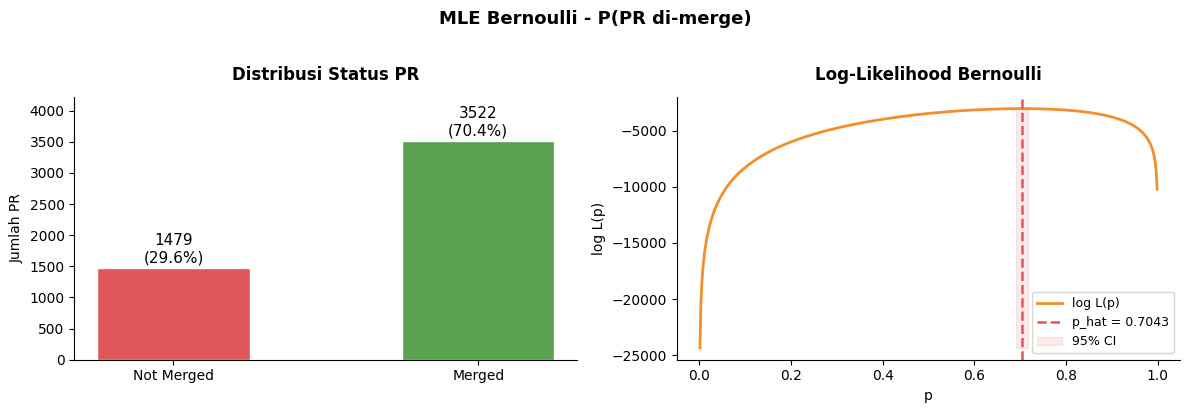

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
counts = [n_pr - k_merge, k_merge]
labels = ["Not Merged", "Merged"]
bars   = ax.bar(labels, counts, color=["#e15759", "#59a14f"],
                edgecolor="white", width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{cnt}\n({cnt/n_pr*100:.1f}%)", ha="center", va="bottom", fontsize=11)
ax.set_title("Distribusi Status PR", fontweight="bold", pad=12)
ax.set_ylabel("Jumlah PR")
ax.set_ylim(0, max(counts) * 1.2)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
p_vals  = np.linspace(0.001, 0.999, 500)
ll_bern = k_merge * np.log(p_vals) + (n_pr - k_merge) * np.log(1 - p_vals)
ax.plot(p_vals, ll_bern, color="#f28e2b", lw=2, label="log L(p)")
ax.axvline(p_mle, color="#e15759", ls="--", lw=1.8,
           label=f"p_hat = {p_mle:.4f}")
ax.fill_betweenx([ll_bern.min(), ll_bern.max()],
                 ci_lo, ci_hi, alpha=0.12, color="#e15759", label="95% CI")
ax.set_title("Log-Likelihood Bernoulli", fontweight="bold", pad=12)
ax.set_xlabel("p")
ax.set_ylabel("log L(p)")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("MLE Bernoulli - P(PR di-merge)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 2. MLE Poisson - Rata-rata Issue per Hari

### Teori
Jumlah issue per hari mengikuti distribusi Poisson:

$$X_i \sim \text{Poisson}(\lambda), \quad X_i \in \{0,1,2,\ldots\}$$

**Log-likelihood:**
$$\ell(\lambda) = \left(\sum_{i=1}^n x_i\right) \ln\lambda - n\lambda - \sum_{i=1}^n \ln(x_i!)$$

**MLE:**

$$lambda\_hat = \bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$$


In [6]:
n_days  = len(issues_count)
lam_mle = issues_count.mean()

se_lam  = np.sqrt(lam_mle / n_days)
ci_lo_l = lam_mle - 1.96 * se_lam
ci_hi_l = lam_mle + 1.96 * se_lam

max_k      = issues_count.max()
obs_freq   = np.bincount(issues_count, minlength=max_k + 1)
exp_freq   = stats.poisson.pmf(np.arange(max_k + 1), lam_mle) * n_days
exp_scaled = exp_freq * (obs_freq.sum() / exp_freq.sum())
chi2_stat, chi2_p = stats.chisquare(obs_freq, f_exp=exp_scaled)

result_pois = pd.DataFrame({
    "Statistik": [
        "Jumlah hari", "Total issue", "lambda_hat (MLE)",
        "SE(lambda_hat)", "95% CI bawah", "95% CI atas",
        "Chi-square (GoF)", "p-value (GoF)"
    ],
    "Nilai": [
        n_days, issues_count.sum(),
        f"{lam_mle:.4f}",
        f"{se_lam:.4f}",
        f"{ci_lo_l:.4f}",
        f"{ci_hi_l:.4f}",
        f"{chi2_stat:.2f}",
        f"{chi2_p:.4f}"
    ]
})
display(result_pois.style.hide(axis="index"))


Statistik,Nilai
Jumlah hari,586
Total issue,5000
lambda_hat (MLE),8.5324
SE(lambda_hat),0.1207
95% CI bawah,8.2959
95% CI atas,8.7689
Chi-square (GoF),86190110404.96
p-value (GoF),0.0000


### Visualisasi MLE Poisson

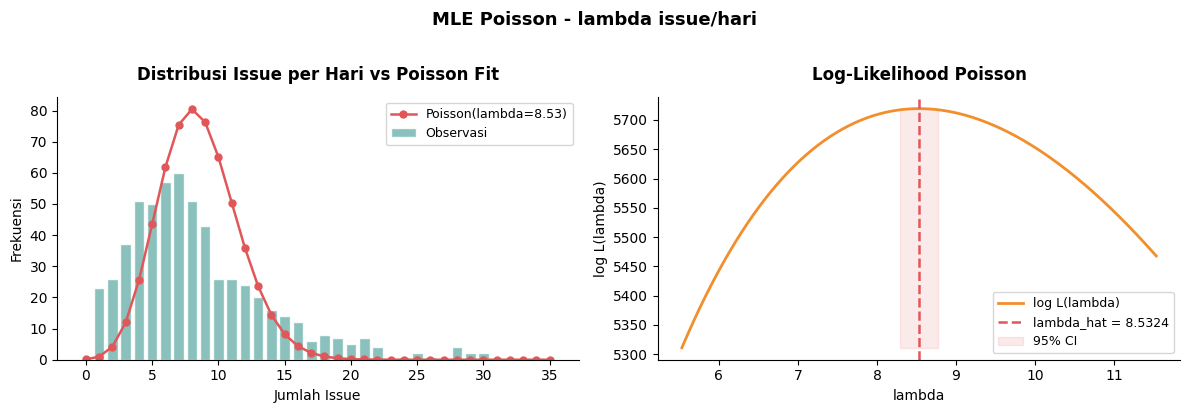

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
max_show = min(issues_count.max(), 35)
x_range  = np.arange(0, max_show + 1)
ax.bar(x_range,
       np.bincount(issues_count, minlength=max_show + 1)[:max_show + 1],
       color="#76b7b2", edgecolor="white", alpha=0.85, label="Observasi")
ax.plot(x_range, stats.poisson.pmf(x_range, lam_mle) * n_days,
        "o-", color="#e15759", ms=5, lw=1.8,
        label=f"Poisson(lambda={lam_mle:.2f})")
ax.set_title("Distribusi Issue per Hari vs Poisson Fit", fontweight="bold", pad=12)
ax.set_xlabel("Jumlah Issue")
ax.set_ylabel("Frekuensi")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
lam_vals = np.linspace(max(0.01, lam_mle - 3), lam_mle + 3, 400)
ll_pois  = issues_count.sum() * np.log(lam_vals) - n_days * lam_vals
ax.plot(lam_vals, ll_pois, color="#f28e2b", lw=2, label="log L(lambda)")
ax.axvline(lam_mle, color="#e15759", ls="--", lw=1.8,
           label=f"lambda_hat = {lam_mle:.4f}")
ax.fill_betweenx([ll_pois.min(), ll_pois.max()],
                 ci_lo_l, ci_hi_l, alpha=0.12, color="#e15759", label="95% CI")
ax.set_title("Log-Likelihood Poisson", fontweight="bold", pad=12)
ax.set_xlabel("lambda")
ax.set_ylabel("log L(lambda)")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("MLE Poisson - lambda issue/hari", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 3. Beta Posterior - Bayesian Update

### Teori (Conjugate Prior)

| Komponen | Distribusi |
|----------|-----------|
| **Prior** | $p \sim \text{Beta}(\alpha_0, \beta_0)$ |
| **Likelihood** | $k \mid p \sim \text{Binomial}(n, p)$ |
| **Posterior** | $p \mid k \sim \text{Beta}(\alpha_0 + k,\ \beta_0 + n - k)$ |

Karena Beta adalah **conjugate prior** dari Binomial, posterior tetap berbentuk Beta.
Parameter update cukup dengan menambahkan observasi:

- alpha_post = alpha_0 + k
- beta_post  = beta_0  + (n - k)

**Posterior mean:**

$$E[p | k] = \frac{\alpha_{post}}{\alpha_{post} + \beta_{post}}$$

> **Prior yang digunakan:** sebelum melihat data, diasumsikan ~60% PR di-merge
> dengan keyakinan setara 20 observasi historis -> Beta(alpha=12, beta=8)


In [8]:
alpha_prior = 12   
beta_prior  = 8   

alpha_post = alpha_prior + k_merge
beta_post  = beta_prior  + (n_pr - k_merge)

post_mean  = alpha_post / (alpha_post + beta_post)
post_mode  = (alpha_post - 1) / (alpha_post + beta_post - 2)
post_var   = (alpha_post * beta_post) /              ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))
post_std   = np.sqrt(post_var)
hdi_lo, hdi_hi = stats.beta.ppf([0.025, 0.975], alpha_post, beta_post)
prior_mean = alpha_prior / (alpha_prior + beta_prior)

result_bayes = pd.DataFrame({
    "Komponen": [
        "Prior", "Prior mean", "Likelihood",
        "Posterior", "Posterior mean", "Posterior mode",
        "Posterior std", "95% Credible Interval"
    ],
    "Nilai": [
        f"Beta(alpha={alpha_prior}, beta={beta_prior})",
        f"{prior_mean:.4f}  ({prior_mean*100:.2f}%)",
        f"Binomial(n={n_pr}, k={k_merge})",
        f"Beta(alpha={alpha_post}, beta={beta_post})",
        f"{post_mean:.4f}  ({post_mean*100:.2f}%)",
        f"{post_mode:.4f}  ({post_mode*100:.2f}%)",
        f"{post_std:.4f}",
        f"[{hdi_lo:.4f}, {hdi_hi:.4f}]"
    ]
})
display(result_bayes.style.hide(axis="index"))


Komponen,Nilai
Prior,"Beta(alpha=12, beta=8)"
Prior mean,0.6000 (60.00%)
Likelihood,"Binomial(n=5001, k=3522)"
Posterior,"Beta(alpha=3534, beta=1487)"
Posterior mean,0.7038 (70.38%)
Posterior mode,0.7039 (70.39%)
Posterior std,0.0064
95% Credible Interval,"[0.6911, 0.7164]"


### Visualisasi Beta Prior vs Posterior

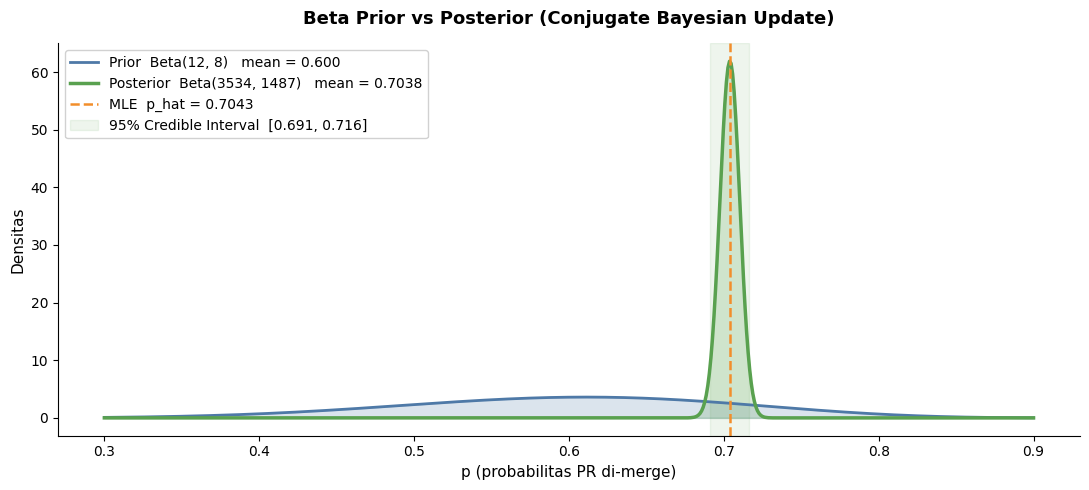

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

p_plot    = np.linspace(0.3, 0.9, 600)
prior_pdf = stats.beta.pdf(p_plot, alpha_prior, beta_prior)
post_pdf  = stats.beta.pdf(p_plot, alpha_post,  beta_post)

ax.fill_between(p_plot, prior_pdf, alpha=0.20, color="#4e79a7")
ax.plot(p_plot, prior_pdf, color="#4e79a7", lw=2,
        label=f"Prior  Beta({alpha_prior}, {beta_prior})   mean = {prior_mean:.3f}")

ax.fill_between(p_plot, post_pdf, alpha=0.20, color="#59a14f")
ax.plot(p_plot, post_pdf, color="#59a14f", lw=2.5,
        label=f"Posterior  Beta({alpha_post}, {beta_post})   mean = {post_mean:.4f}")

ax.axvline(p_mle, color="#f28e2b", ls="--", lw=1.8,
           label=f"MLE  p_hat = {p_mle:.4f}")
ax.axvspan(hdi_lo, hdi_hi, alpha=0.10, color="#59a14f",
           label=f"95% Credible Interval  [{hdi_lo:.3f}, {hdi_hi:.3f}]")

ax.set_title("Beta Prior vs Posterior (Conjugate Bayesian Update)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("p (probabilitas PR di-merge)", fontsize=11)
ax.set_ylabel("Densitas", fontsize=11)
ax.legend(fontsize=10, loc="upper left", framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## 4. Dashboard Ringkasan - Semua Analisis

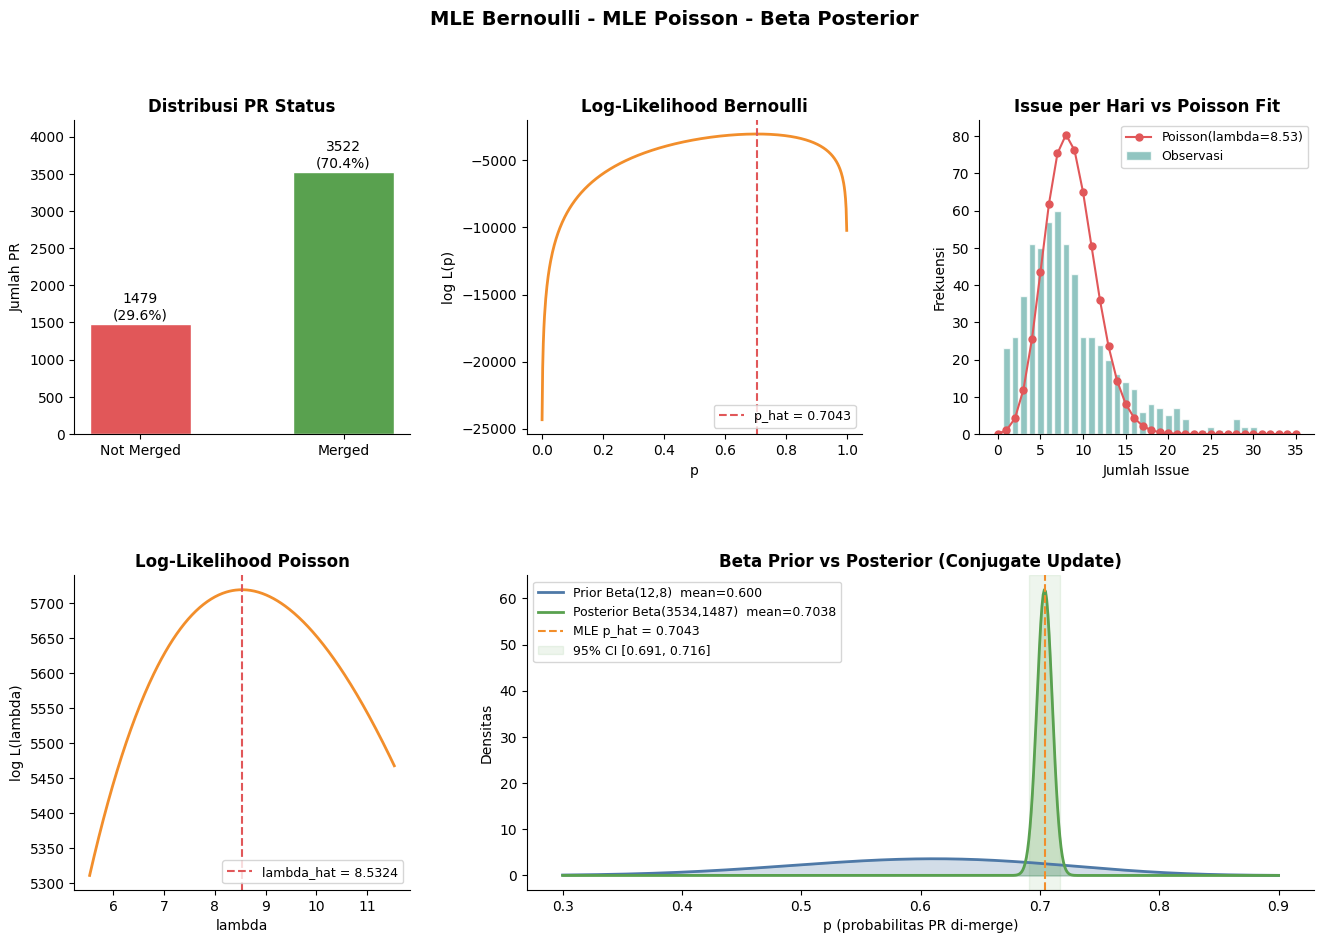

Dashboard disimpan ke bayesian_analysis.png


In [10]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("MLE Bernoulli - MLE Poisson - Beta Posterior",
             fontsize=14, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = {
    "prior"      : "#4e79a7",
    "likelihood" : "#f28e2b",
    "posterior"  : "#59a14f",
    "bar"        : "#76b7b2"
}

ax1 = fig.add_subplot(gs[0, 0])
counts = [n_pr - k_merge, k_merge]
labels = ["Not Merged", "Merged"]
bars   = ax1.bar(labels, counts, color=["#e15759", "#59a14f"],
                 edgecolor="white", width=0.5)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{cnt}\n({cnt/n_pr*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax1.set_title("Distribusi PR Status", fontweight="bold")
ax1.set_ylabel("Jumlah PR")
ax1.set_ylim(0, max(counts) * 1.2)
ax1.spines[["top", "right"]].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
p_vals  = np.linspace(0.001, 0.999, 500)
ll_bern = k_merge * np.log(p_vals) + (n_pr - k_merge) * np.log(1 - p_vals)
ax2.plot(p_vals, ll_bern, color=colors["likelihood"], lw=2)
ax2.axvline(p_mle, color="#e15759", ls="--", lw=1.5,
            label=f"p_hat = {p_mle:.4f}")
ax2.set_title("Log-Likelihood Bernoulli", fontweight="bold")
ax2.set_xlabel("p")
ax2.set_ylabel("log L(p)")
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
max_show = min(issues_count.max(), 35)
x_range  = np.arange(0, max_show + 1)
ax3.bar(x_range,
        np.bincount(issues_count, minlength=max_show + 1)[:max_show + 1],
        color=colors["bar"], edgecolor="white", alpha=0.8, label="Observasi")
ax3.plot(x_range, stats.poisson.pmf(x_range, lam_mle) * n_days,
         "o-", color="#e15759", ms=5, lw=1.5,
         label=f"Poisson(lambda={lam_mle:.2f})")
ax3.set_title("Issue per Hari vs Poisson Fit", fontweight="bold")
ax3.set_xlabel("Jumlah Issue")
ax3.set_ylabel("Frekuensi")
ax3.legend(fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0])
lam_vals = np.linspace(max(0.01, lam_mle - 3), lam_mle + 3, 400)
ll_pois  = issues_count.sum() * np.log(lam_vals) - n_days * lam_vals
ax4.plot(lam_vals, ll_pois, color=colors["likelihood"], lw=2)
ax4.axvline(lam_mle, color="#e15759", ls="--", lw=1.5,
            label=f"lambda_hat = {lam_mle:.4f}")
ax4.set_title("Log-Likelihood Poisson", fontweight="bold")
ax4.set_xlabel("lambda")
ax4.set_ylabel("log L(lambda)")
ax4.legend(fontsize=9)
ax4.spines[["top", "right"]].set_visible(False)

ax5 = fig.add_subplot(gs[1, 1:])
p_plot    = np.linspace(0.3, 0.9, 600)
prior_pdf = stats.beta.pdf(p_plot, alpha_prior, beta_prior)
post_pdf  = stats.beta.pdf(p_plot, alpha_post,  beta_post)
ax5.fill_between(p_plot, prior_pdf, alpha=0.25, color=colors["prior"])
ax5.plot(p_plot, prior_pdf, color=colors["prior"], lw=2,
         label=f"Prior Beta({alpha_prior},{beta_prior})  mean={prior_mean:.3f}")
ax5.fill_between(p_plot, post_pdf, alpha=0.25, color=colors["posterior"])
ax5.plot(p_plot, post_pdf, color=colors["posterior"], lw=2,
         label=f"Posterior Beta({alpha_post},{beta_post})  mean={post_mean:.4f}")
ax5.axvline(p_mle, color=colors["likelihood"], ls="--", lw=1.5,
            label=f"MLE p_hat = {p_mle:.4f}")
ax5.axvspan(hdi_lo, hdi_hi, alpha=0.10, color=colors["posterior"],
            label=f"95% CI [{hdi_lo:.3f}, {hdi_hi:.3f}]")
ax5.set_title("Beta Prior vs Posterior (Conjugate Update)", fontweight="bold")
ax5.set_xlabel("p (probabilitas PR di-merge)")
ax5.set_ylabel("Densitas")
ax5.legend(fontsize=9, loc="upper left")
ax5.spines[["top", "right"]].set_visible(False)

plt.savefig("bayesian_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard disimpan ke bayesian_analysis.png")


## 5. Kesimpulan Akhir

In [11]:
summary = pd.DataFrame({
    "Analisis": [
        "MLE Bernoulli",
        "MLE Poisson",
        "Beta Prior",
        "Beta Posterior",
    ],
    "Parameter": ["p_hat", "lambda_hat", "alpha_0, beta_0", "alpha, beta"],
    "Nilai": [
        f"{p_mle:.4f}  ({p_mle*100:.2f}%)",
        f"{lam_mle:.4f} issue/hari",
        f"Beta({alpha_prior}, {beta_prior})  mean = {prior_mean:.4f}",
        f"Beta({alpha_post}, {beta_post})  mean = {post_mean:.4f}",
    ],
    "95% Interval": [
        f"[{ci_lo:.4f}, {ci_hi:.4f}]",
        f"[{ci_lo_l:.4f}, {ci_hi_l:.4f}]",
        "-",
        f"[{hdi_lo:.4f}, {hdi_hi:.4f}]",
    ],
    "Interpretasi": [
        "70.42% PR berhasil di-merge",
        "Rata-rata ~8.5 issue masuk per hari",
        "Prior belief: 60% PR di-merge (sebelum data)",
        "Setelah 5000 data: belief diperbarui ke ~70.38%",
    ]
})
display(summary.style.hide(axis="index")
        .set_properties(**{"text-align": "left"})
        .set_table_styles([
            {"selector": "th", "props": [("font-weight", "bold"), ("text-align", "left")]},
        ]))


Analisis,Parameter,Nilai,95% Interval,Interpretasi
MLE Bernoulli,p_hat,0.7043 (70.43%),"[0.6916, 0.7169]",70.42% PR berhasil di-merge
MLE Poisson,lambda_hat,8.5324 issue/hari,"[8.2959, 8.7689]",Rata-rata ~8.5 issue masuk per hari
Beta Prior,"alpha_0, beta_0","Beta(12, 8) mean = 0.6000",-,Prior belief: 60% PR di-merge (sebelum data)
Beta Posterior,"alpha, beta","Beta(3534, 1487) mean = 0.7038","[0.6911, 0.7164]",Setelah 5000 data: belief diperbarui ke ~70.38%
